# K Means Clustering

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [6]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 42)

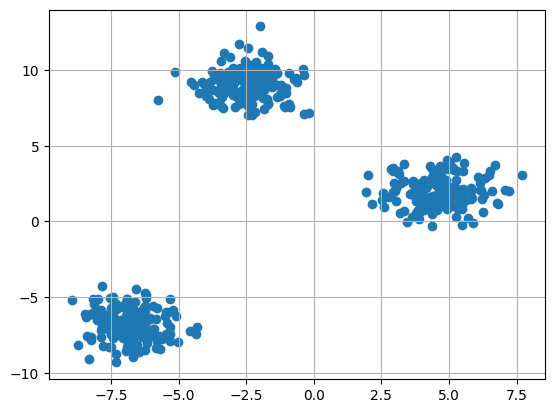

In [7]:
fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [12]:
X.shape,X.shape[1]

((500, 2), 2)

In [48]:
2*(2*np.random.random((X.shape[1])))-1

array([-0.70179743,  2.94754775])

In [49]:
center = 2*(2*np.random.random((X.shape[1],))-1)

In [8]:
k = 3
clusters = {}
np.random.seed(42)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([-0.50183952,  1.80285723]), 'points': []},
 1: {'center': array([0.92797577, 0.39463394]), 'points': []},
 2: {'center': array([-1.37592544, -1.37602192]), 'points': []}}

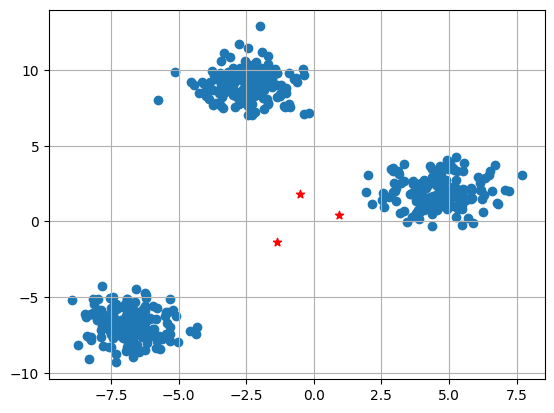

In [50]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

In [51]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [54]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

In [55]:
def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

In [56]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred 

In [57]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

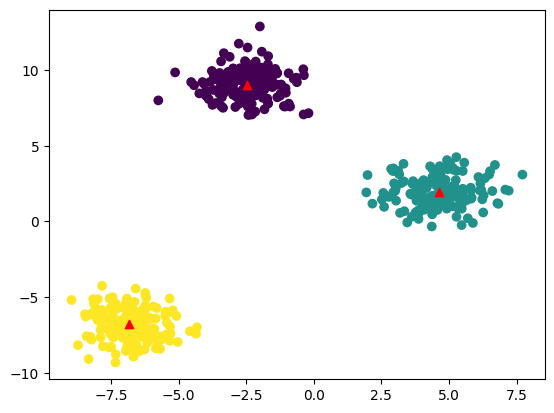

In [58]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

## NOW USING SKLEARN

In [59]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [63]:
df = pd.read_csv("Data/income.csv")
df.head()

,Age,Income($)
0,26,22923
1,24,27896
2,26,28286
3,29,25988
4,24,29193


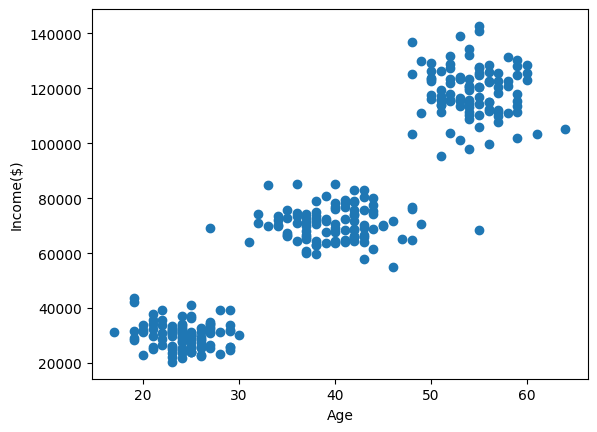

In [64]:
plt.scatter(df.Age,df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.show()